# Downstream Evaluation: RankMe Evolution → Multilingual Performance

**Research question:** *Does the shape of the RankMe trajectory during pre-training predict downstream multilingual performance? Specifically: does the point where compression begins (onset) and how long it lasts (duration) correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)  
**Geometry source:** Wikipedia samples via FineWeb-2 (`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`)

### What this notebook does
1. **Phase identification** — detects two training phases from the RankMe curve: an *entropy-seeking* phase (RankMe ↑, the model builds richer representations) and a *compression-seeking* phase (RankMe ↓, the model specialises and compresses). For each phase, **onset** is the token count (in billions) where the phase begins, and **duration** is how long it lasts.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints. Requires downstream eval results.
3. **Correlation analysis** — Spearman + Pearson tests: *does an earlier or longer compression phase predict earlier or higher accuracy?* Computed separately per task (m-MMLU / XCOPA), never pooled across tasks.
4. **Plots** — RankMe trajectories, phase overlays, dual-axis accuracy curves, and correlation scatter plots; all per-model plots include the model name in the filename.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [1]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_phases, compute_alpha_phases,
    compute_grokking,
    compute_correlations_table, compute_alpha_correlations_table,
    plot_rankme_phases, plot_overlay,
    plot_alpha_phases, plot_alpha_overlay,
    plot_rankme_last_scatter_combined, plot_correlation_scatter_combined,
    plot_alpha_correlation_scatter_combined, plot_alpha_rate_scatter_combined,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `load_config()` derives all paths, layer settings, grokking parameters, and benchmark metadata from `configs/benchmarks.yaml`.

Per-model plots (trajectories, phase overlays) are saved with the model name in the filename (e.g. `rankme_phases_fuxi.png`, `overlay_m_mmlu_apertus.png`). Combined scatter plots overlay both models in a single file.

In [2]:
MODELS = ["fuxi", "apertus"]

# Per-model colors and markers used in combined scatter plots.
_PALETTE = {
    "fuxi":    {"color": "steelblue",  "marker": "o"},
    "apertus": {"color": "darkorange", "marker": "s"},
}

data = {}
for m in MODELS:
    cfg = load_config(m)
    data[m] = {
        "cfg":    cfg,
        "color":  _PALETTE[m]["color"],
        "marker": _PALETTE[m]["marker"],
    }
    print(f"[{m}] {cfg['model_label']}  |  Layer: {cfg['layer']}  |  Aggregation: {cfg['aggregation']}")

[fuxi] FuxiTranyu-8B  |  Layer: layer_29  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_31  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_29`, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run.

- **`fuxi_fine_wiki_merged.csv` / `apertus_fine_wiki_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Only contains the checkpoints that have been evaluated. Used for grokking detection, correlation analysis, and overlay plots.

The phase plots use the full geometry data (all checkpoints). The accuracy-based plots use only the evaluated checkpoints.

In [3]:
for m in MODELS:
    cfg = data[m]["cfg"]
    df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(
        cfg["rankme_csv"], cfg["layer"], cfg["aggregation"])
    df_eval, eval_available = load_eval_data(cfg["merged_csv"])
    data[m].update({
        "df_rankme":       df_rankme,
        "df_layer":        df_layer,
        "checkpoints_all": checkpoints_all,
        "token_counts":    token_counts,
        "langs_sorted":    langs_sorted,
        "df_eval":         df_eval,
        "eval_available":  eval_available,
    })
    print()

Loaded RankMe: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_29, agg=last → 798 rows
Loaded eval: 741 records — 2 task(s), 57 checkpoint(s)

Loaded RankMe: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_31, agg=last → 616 rows
Loaded eval: 572 records — 2 task(s), 44 checkpoint(s)



## Phase Identification

The RankMe curve is split into two phases by locating its global peak:

- **Entropy-seeking** — from the first observed checkpoint to the peak (RankMe ↑). The model is building richer, more diverse representations.
- **Compression-seeking** — from the peak to the end of training (RankMe ↓). The model specialises and compresses its representations.

For each phase, **onset** is the token count where it begins and **duration** is how long it lasts. All token values are in **billions (B)**.

A phase is `NaN` when it cannot be observed in the available data:
- **Entropy NaN** — the peak is at the very first checkpoint we have, meaning the entropy-seeking phase either happened before training began or before the earliest checkpoint recorded. This is the case for FuxiTranyu-8B, where RankMe is highest at 10B tokens and decreases from there.
- **Compression NaN** — RankMe never falls after the peak, so no compression phase is detected.

In [4]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_phases = compute_phases(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_phases"] = df_phases

    display_cols = {
        "language":                    "language",
        "peak_tokens":                 "peak (B)",
        "entropy_onset_tokens":        "entropy onset (B)",
        "entropy_duration_tokens":     "entropy duration (B)",
        "compression_onset_tokens":    "compression onset (B)",
        "compression_duration_tokens": "compression duration (B)",
        "rankme_first":                "RankMe first ckpt",
        "rankme_last":                 "RankMe last ckpt",
        "rankme_decline_rate":         "decline rate (1/B)",
    }
    print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
    print(df_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))


── FuxiTranyu-8B ────────────────────────────────────────
  language  peak (B)  entropy onset (B)  entropy duration (B)  compression onset (B)  compression duration (B)  RankMe first ckpt  RankMe last ckpt  decline rate (1/B)
    Arabic      10.0                NaN                   NaN                   10.0                     583.0           117.9297           77.6066            0.069165
   Chinese      10.0                NaN                   NaN                   10.0                     583.0           302.4599          157.0904            0.249347
   English      10.0                NaN                   NaN                   10.0                     583.0           268.1290          125.4628            0.244710
   Finnish      10.0                NaN                   NaN                   10.0                     583.0           123.1964           69.6830            0.091790
    French      10.0                NaN                   NaN                   10.0                 

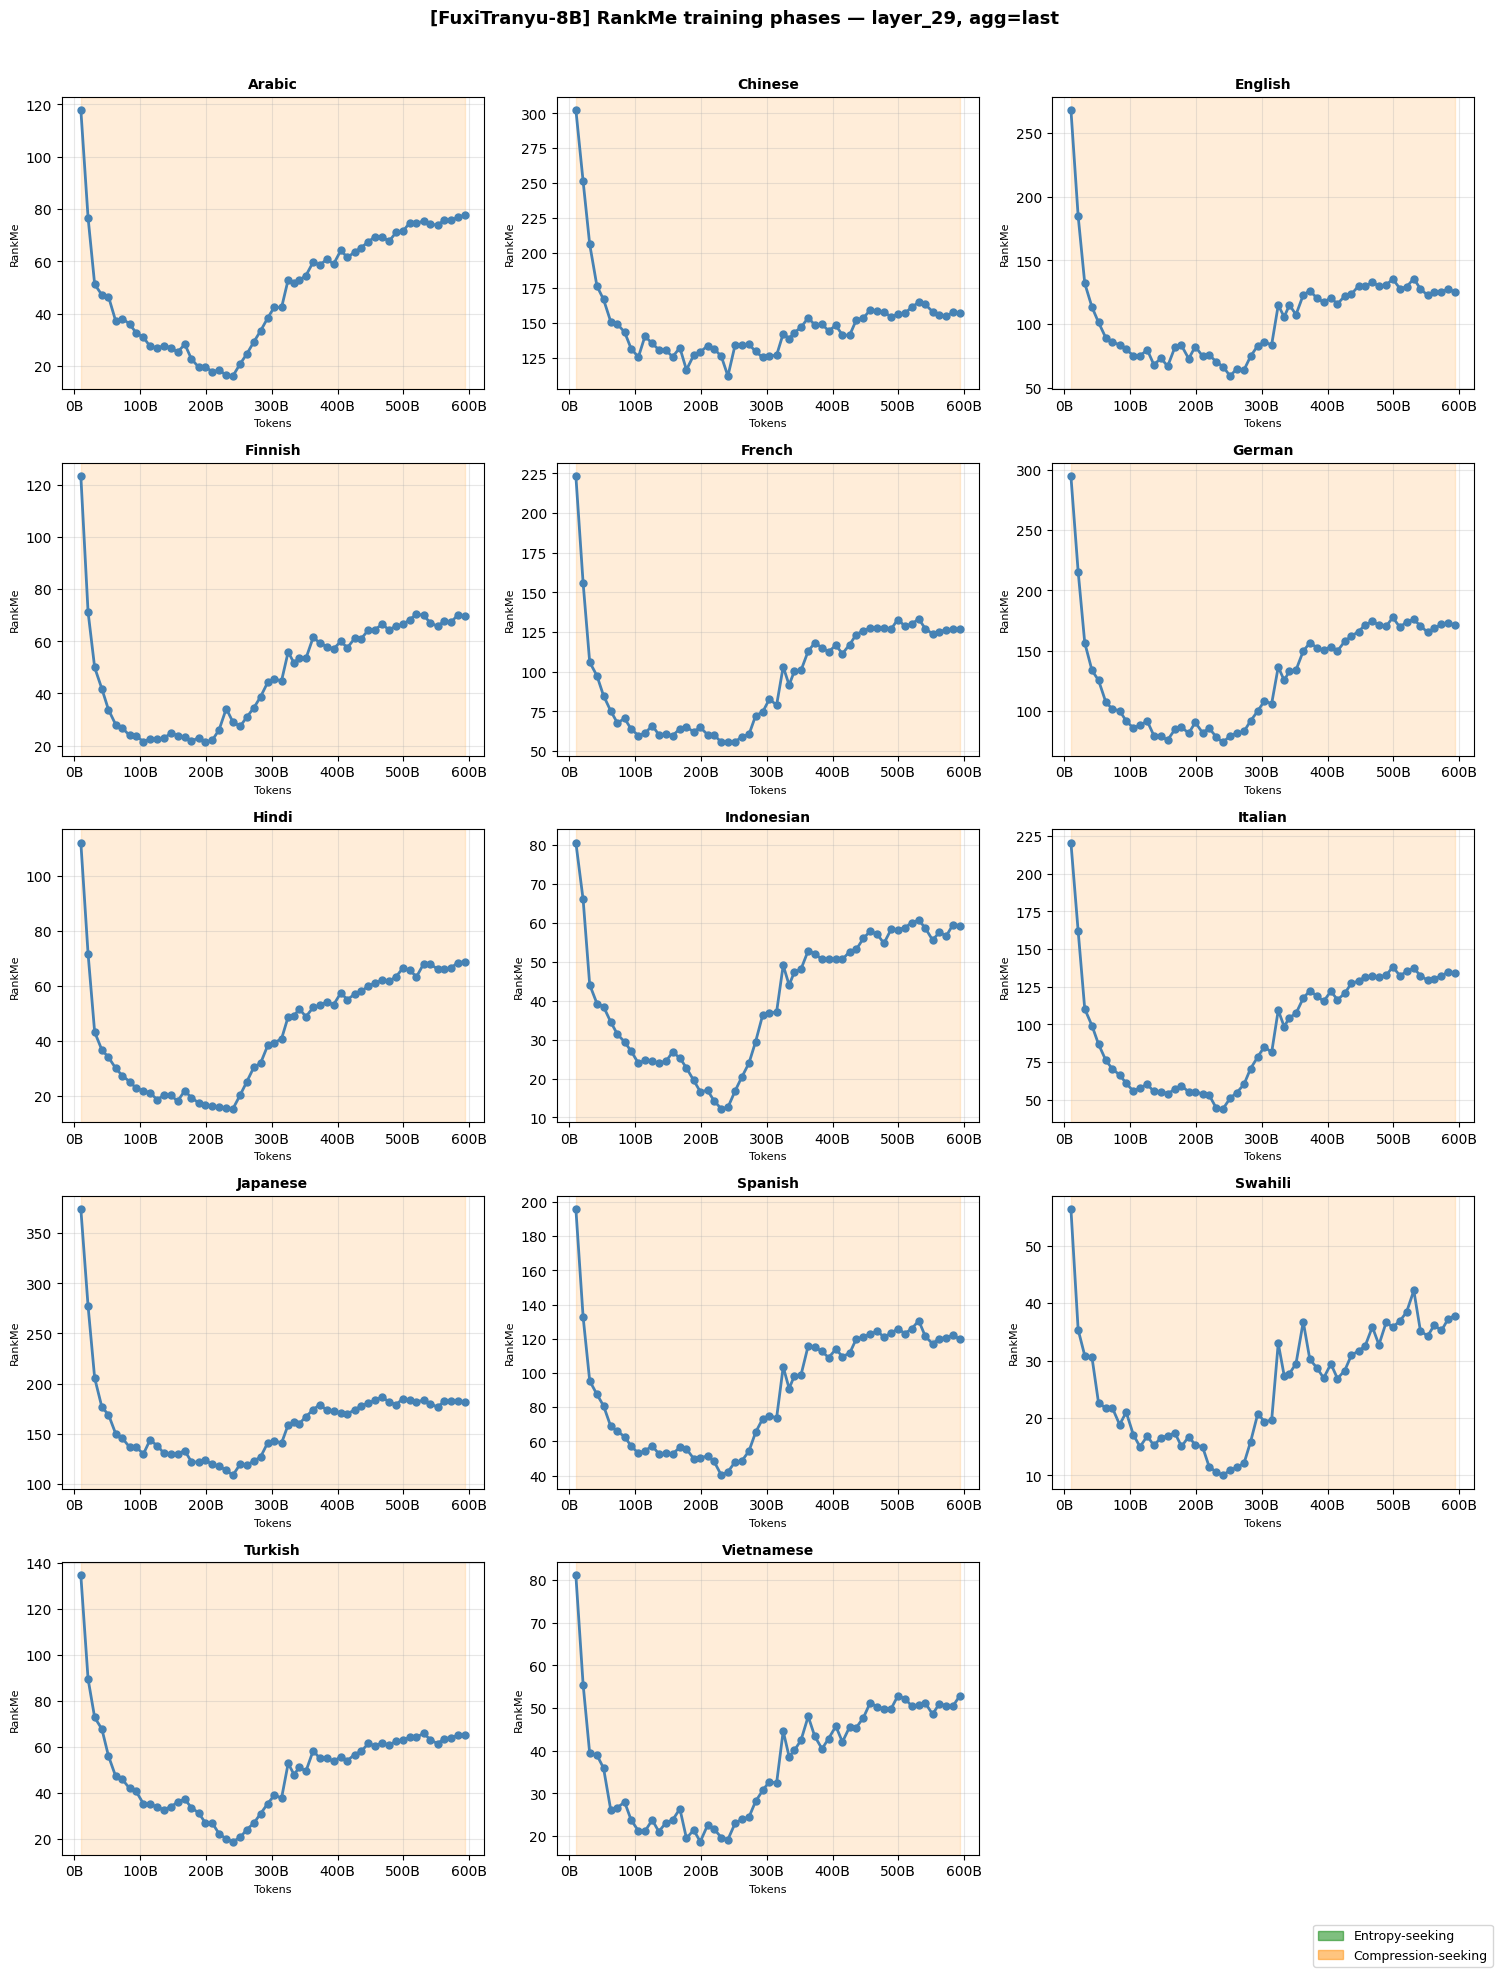

Saved: plots/rankme_phases_fuxi.png


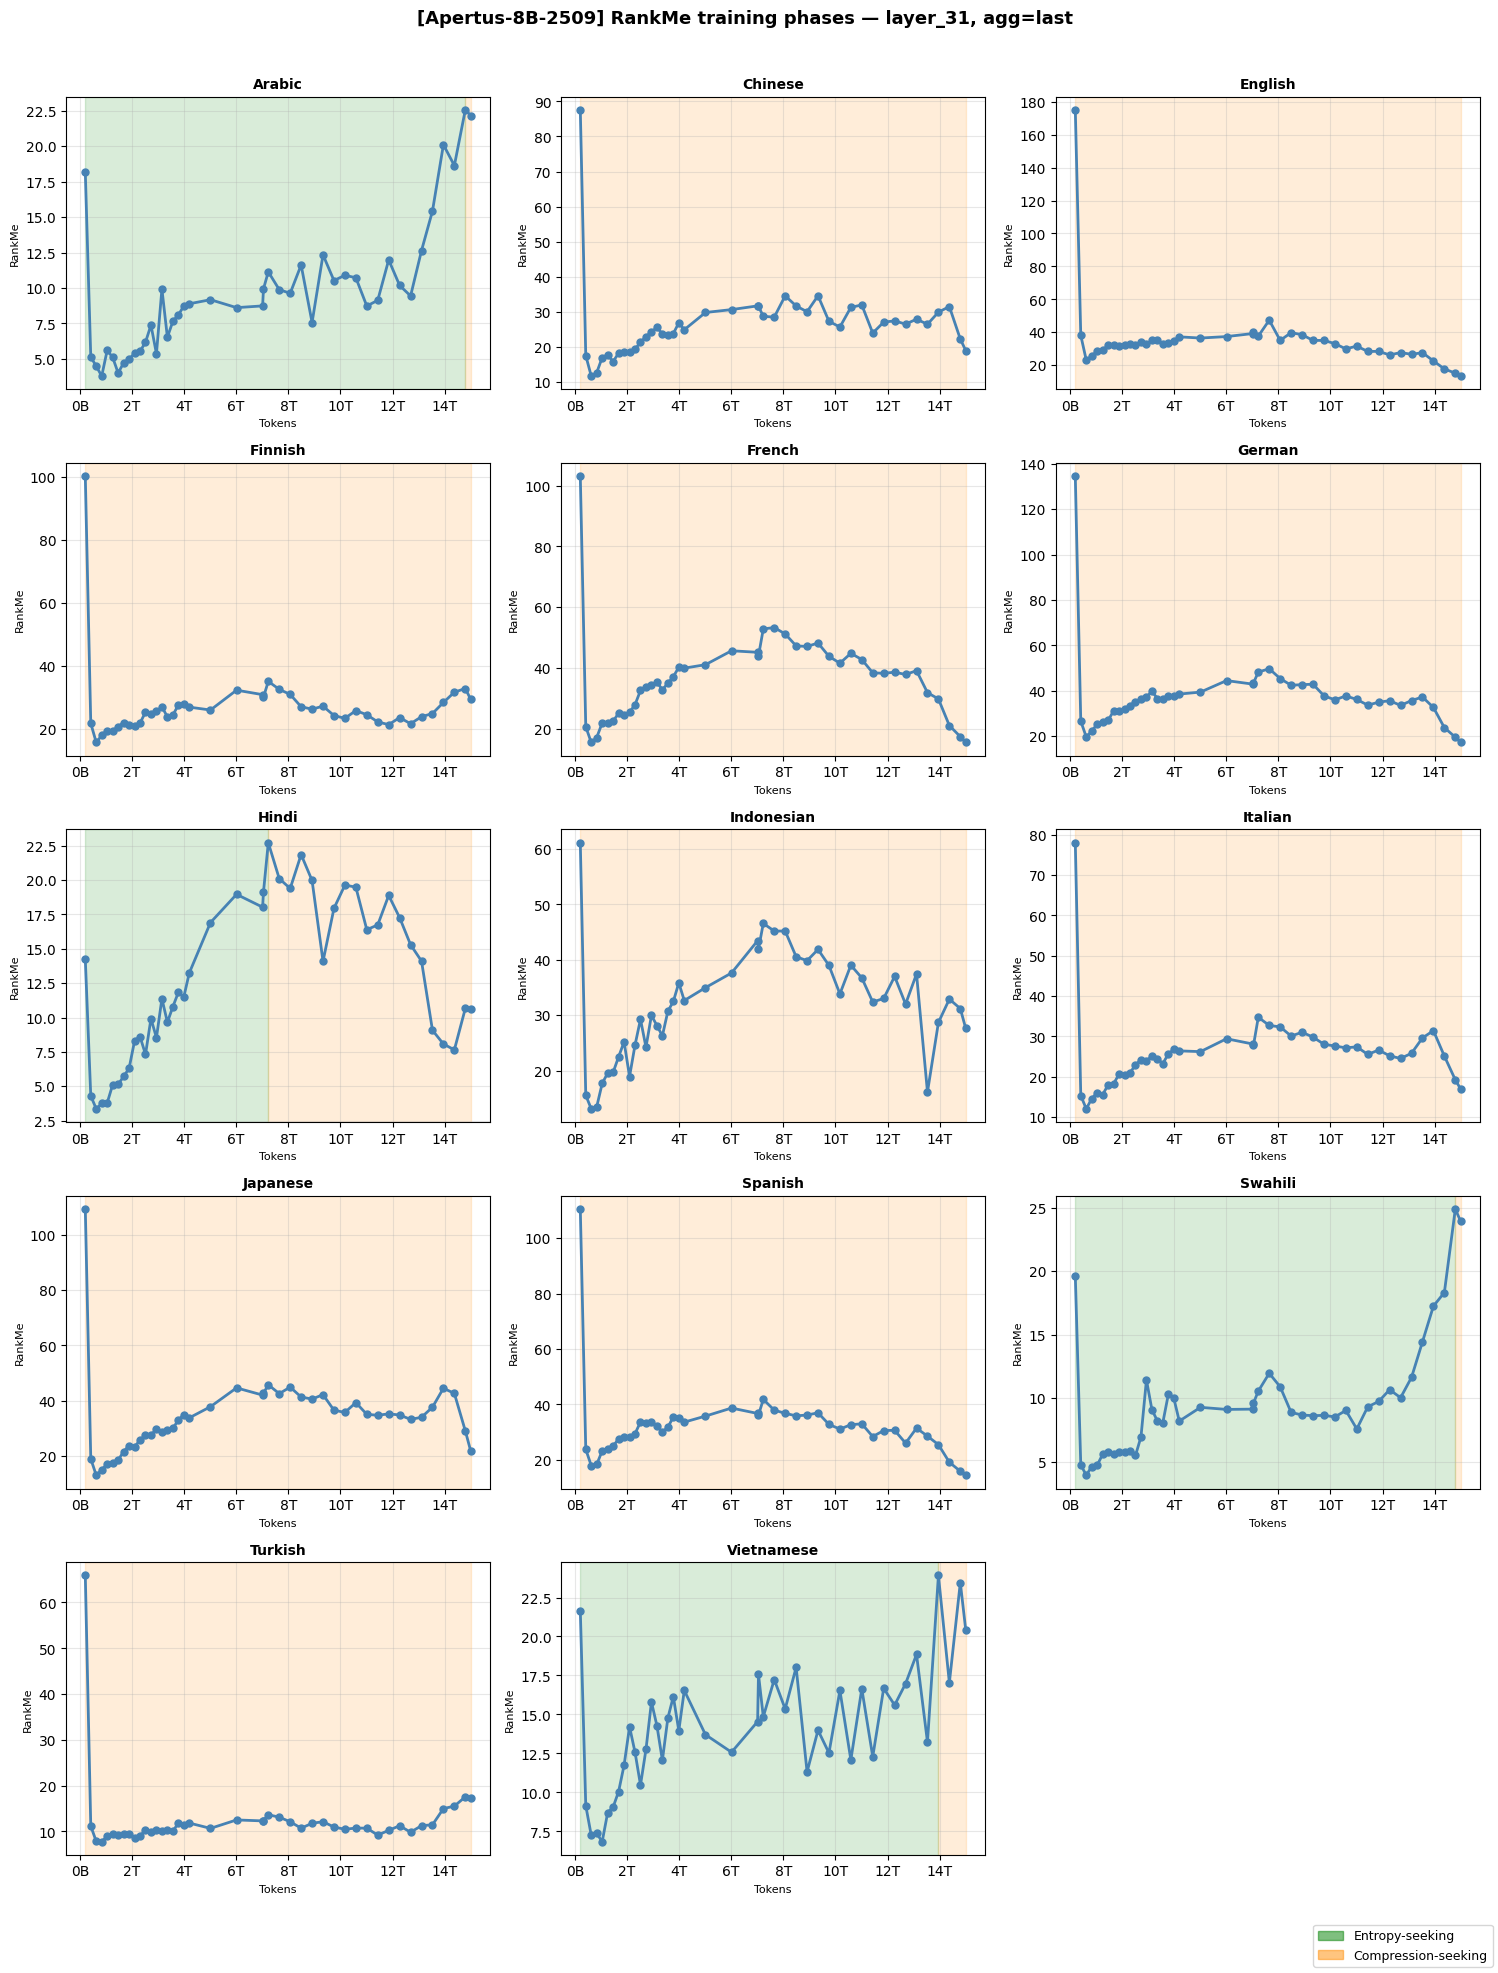

Saved: plots/rankme_phases_apertus.png


In [5]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    plot_rankme_phases(d["df_layer"], d["df_phases"], d["checkpoints_all"], d["token_counts"],
                       d["langs_sorted"], cfg["model_label"], cfg["layer"], cfg["aggregation"],
                       cfg["plots_dir"], model_key=m)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task:

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all evaluated checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any evaluated checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [6]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        df_grokking = compute_grokking(d["df_eval"], cfg["task_languages"], cfg["random_chance"],
                                       threshold=cfg["grokking_threshold"],
                                       min_consecutive=cfg["grokking_min_consec"])
        d["df_grokking"] = df_grokking
        display_cols = {
            "task":            "task",
            "language":        "language",
            "grokking_tokens": "grokking onset (B)",
            "peak_tokens":     "peak (B)",
            "peak_accuracy":   "peak accuracy",
            "random_chance":   "random chance",
        }
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
    else:
        d["df_grokking"] = pd.DataFrame()
        print(f"[{m}] No eval data — run submit_eval.sh + merge_results.py first.")


── FuxiTranyu-8B ────────────────────────────────────────
  task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
m_mmlu    English                 NaN     115.0       0.272590           0.25
m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
m_mmlu     German                 NaN     199.0       0.274928           0.25
m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
m_mmlu    Italian                 NaN     415.0       0.275818           0.25
m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
 xcopa    Chinese               325.0     426.0       0.664000           0.50
 xcopa    Italian               241.0     520.0       0.718000           0.50
 xcopa Vietnamese               126.0     436.0       0.736000           0.50
 xcop

## Correlation Analysis

Tests whether RankMe phase geometry predicts downstream performance. Five predictors are tested against two outcomes, separately per task:

**Timing-based (may have zero variance if all languages peak at the same checkpoint):**
- **Compression onset (B)** — how early the compression phase begins.
- **Compression duration (B)** — how long the compression phase lasts.

**Magnitude-based (vary across languages regardless of when the peak occurs):**
- **RankMe at first ckpt** — representation richness at the start of training.
- **RankMe at last ckpt** — representation richness at the end of training.
- **Rate of RankMe decline (1/B)** — (RankMe[first] − RankMe[last]) / total training tokens; how aggressively the model compresses each language's representations.

Outcomes:
- **Grokking onset (B)** — when accuracy first crosses the threshold.
- **Peak accuracy** — highest accuracy across all evaluated checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [7]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_grokking"].empty:
        df_correlations = compute_correlations_table(d["df_grokking"], d["df_phases"])
        d["df_correlations"] = df_correlations
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_correlations.to_string(index=False))
    else:
        d["df_correlations"] = pd.DataFrame()
        print(f"[{m}] Skipping correlation analysis — no eval data available.")


── FuxiTranyu-8B ────────────────────────────────────────
  task                predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu        Compression onset (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu        Compression onset (B)      Peak accuracy            8         NaN         NaN        NaN        NaN
m_mmlu     Compression duration (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu     Compression duration (B)      Peak accuracy            8         NaN         NaN        NaN        NaN
m_mmlu         RankMe at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu         RankMe at first ckpt      Peak accuracy            8      0.0952      0.8225     0.3315     0.4225
m_mmlu          RankMe at last ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu          RankMe at las

The scatter plot below visualises compression onset vs peak accuracy (one panel per task) with labeled points per language and a linear regression line.

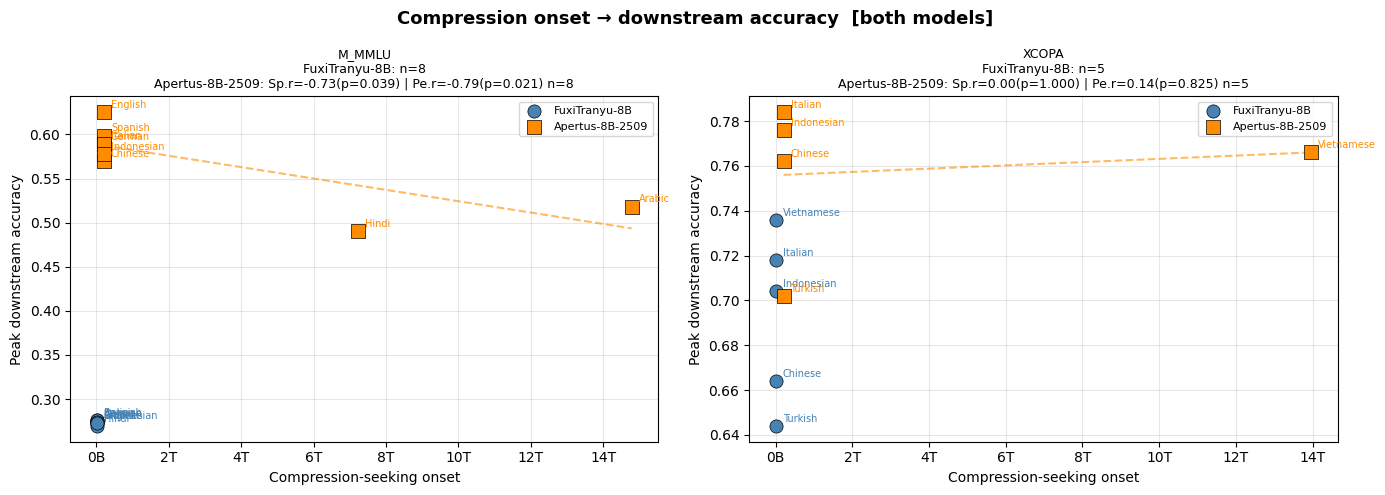

Saved: plots/correlation_scatter.png


In [8]:
models_data = [
    {
        "label":       data[m]["cfg"]["model_label"],
        "df_grokking": data[m].get("df_grokking", pd.DataFrame()),
        "df_phases":   data[m].get("df_phases",   pd.DataFrame()),
        "color":       data[m]["color"],
        "marker":      data[m]["marker"],
    }
    for m in MODELS if data[m]["eval_available"]
]
if models_data:
    plot_correlation_scatter_combined(models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping correlation scatter — no eval data available.")

**FuxiTranyu-8B:** RankMe at the last checkpoint shows a marginal positive correlation with XCOPA grokking onset (Spearman r=+0.95, p=0.051, n=4) — higher final RankMe is associated with *later* grokking, a counterintuitive direction that does not reach significance. No significant correlation with peak accuracy (Sp r=−0.50, p=0.39, n=5). RankMe geometry does not predict XCOPA outcomes for this model.

**Apertus-8B-2509:** RankMe at the first checkpoint strongly predicts peak m-MMLU accuracy (Sp r=+0.83, p=0.010; Pearson r=+0.90, p=0.002, n=8) — see the m-MMLU panel above and the RankMe Findings section below for full discussion.

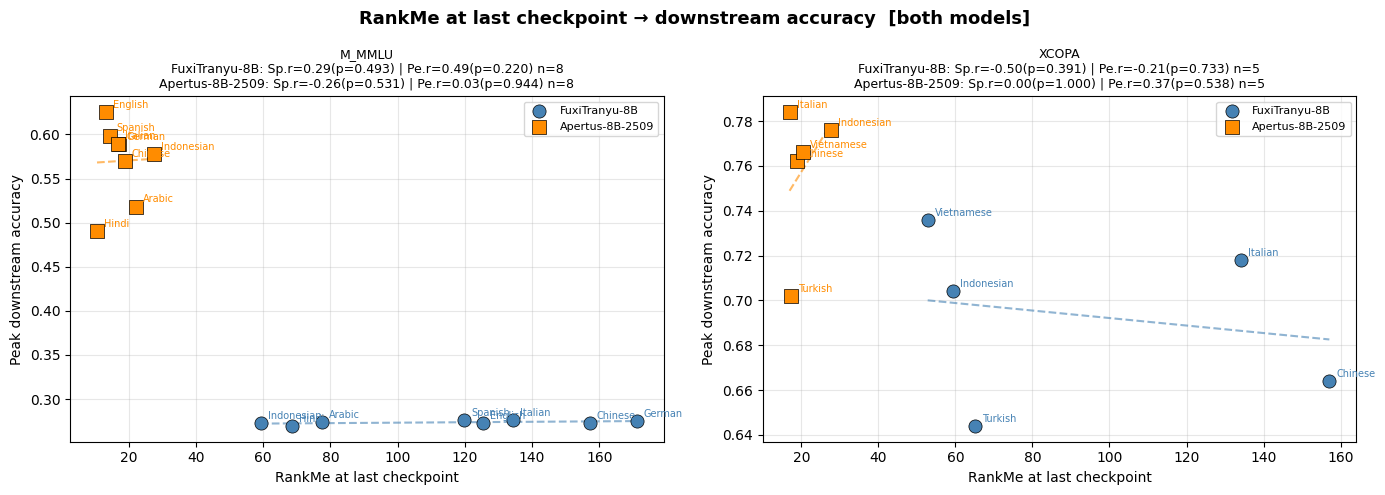

Saved: plots/rankme_last_scatter.png


In [9]:
if models_data:
    plot_rankme_last_scatter_combined(models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping RankMe last checkpoint scatter — no eval data available.")

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language that appears in both the RankMe data and the evaluation results. Each panel shows two y-axes:

- **Left axis (blue)** — RankMe trajectory across all checkpoints, showing the full geometry evolution during pre-training.
- **Right axis (red, dashed)** — downstream accuracy at the evaluated checkpoints only. The axis always spans 0 to 1.

The shaded regions mark the two training phases (green = entropy-seeking, orange = compression-seeking). The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — it is absent when grokking was not detected (accuracy never exceeded the threshold for 2 consecutive checkpoints).

These plots let you visually inspect whether accuracy rises during or after the compression phase, and whether grokking coincides with any particular point in the RankMe trajectory.

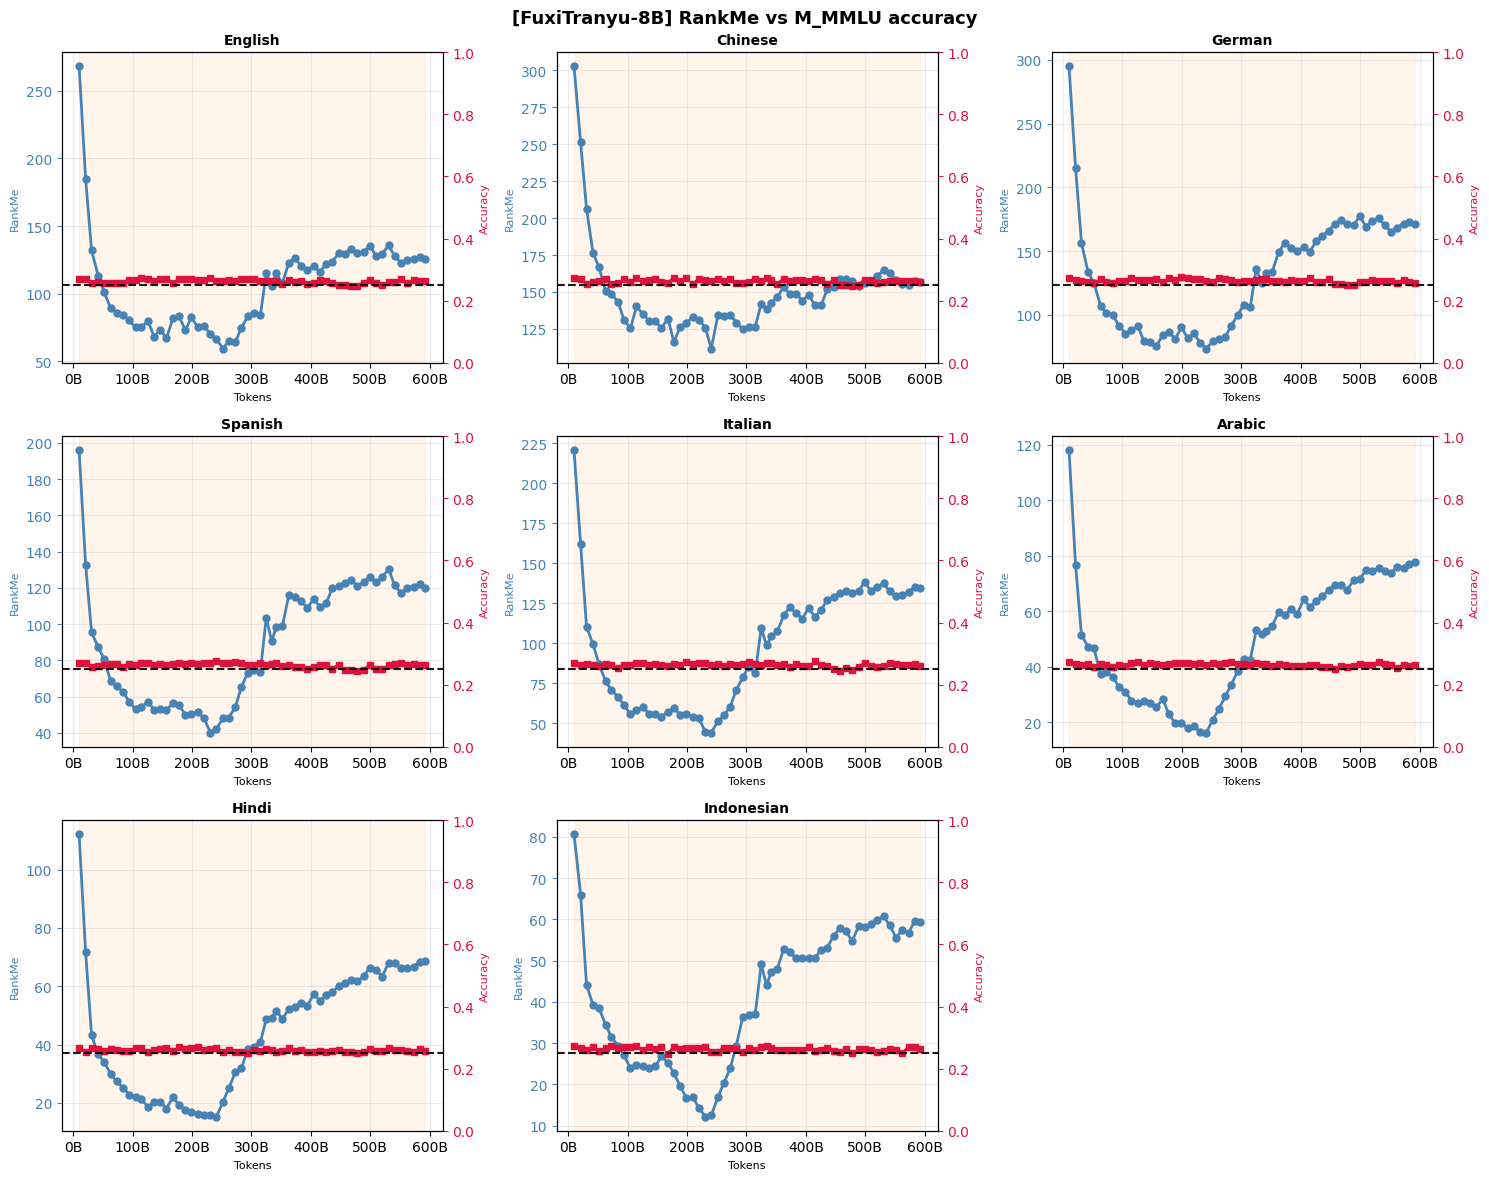

Saved: plots/overlay_m_mmlu_fuxi.png


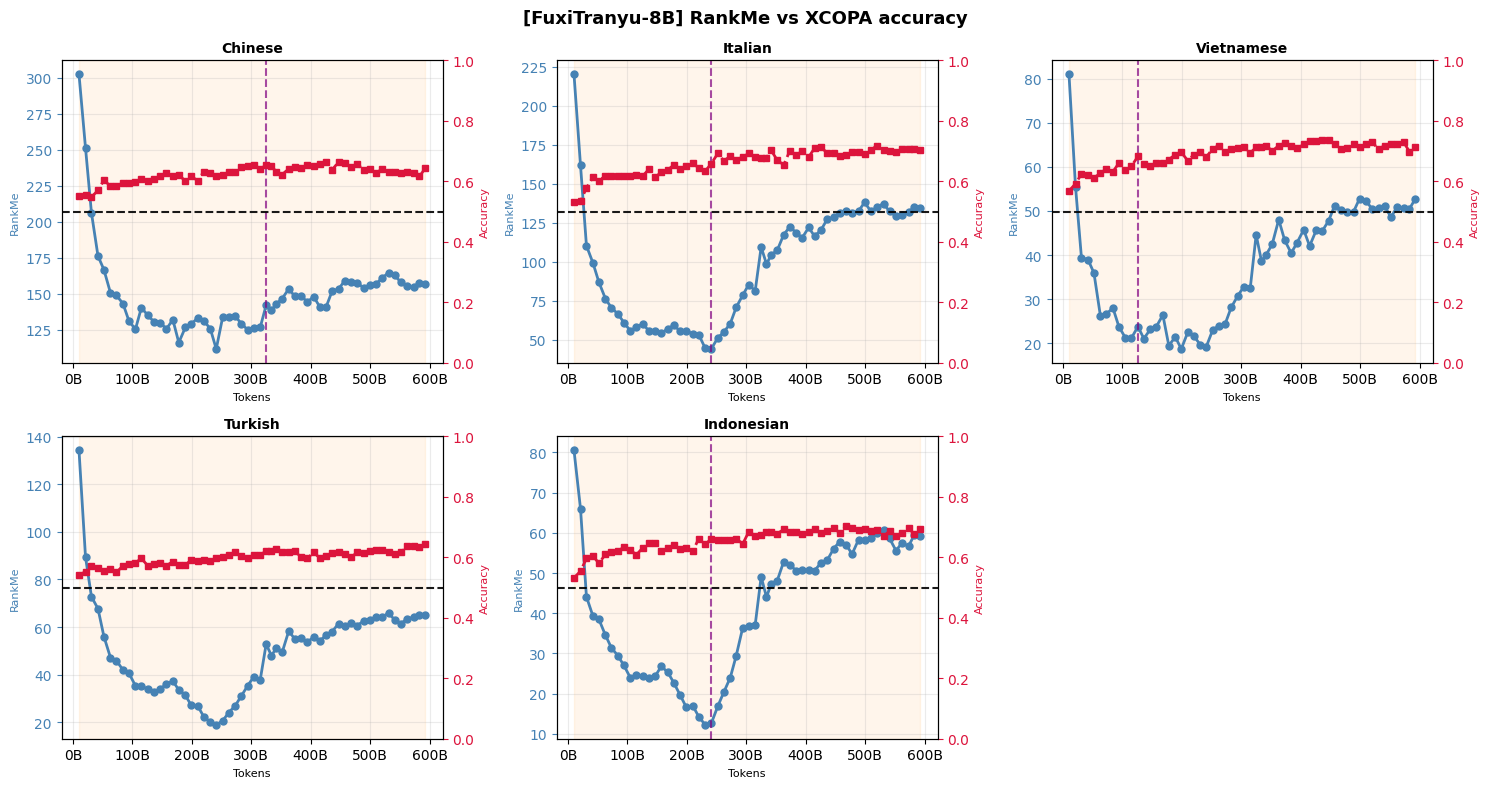

Saved: plots/overlay_xcopa_fuxi.png


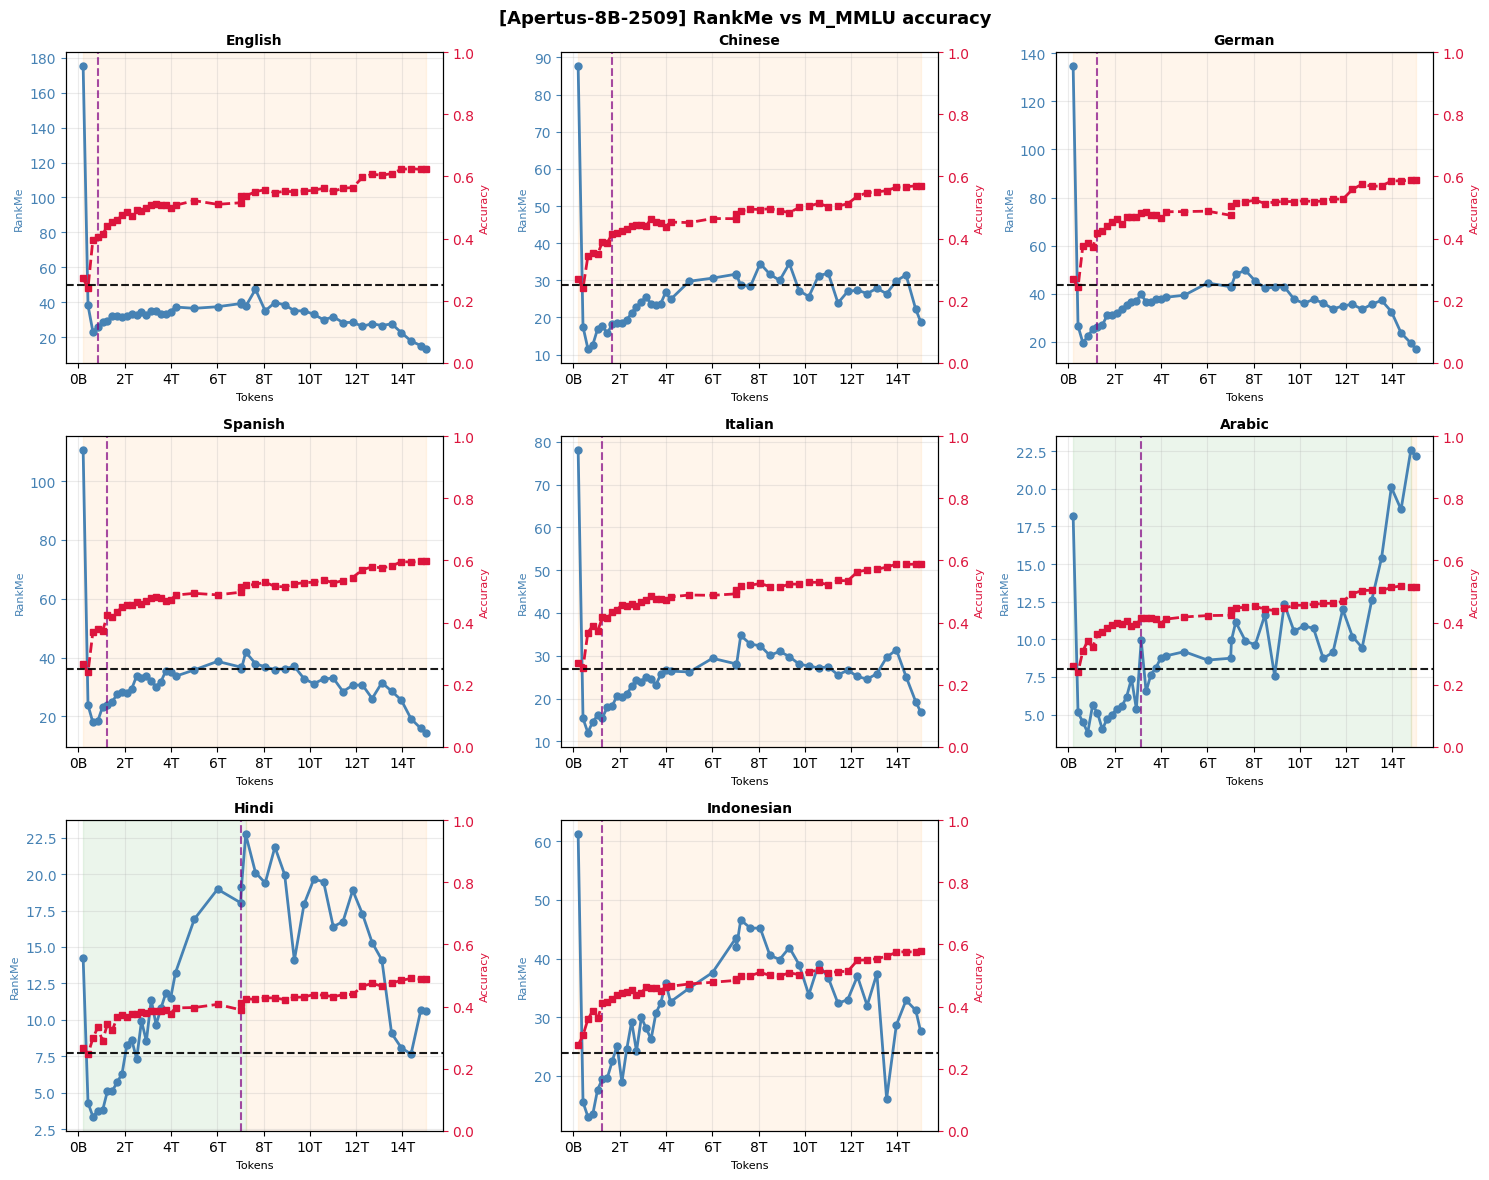

Saved: plots/overlay_m_mmlu_apertus.png


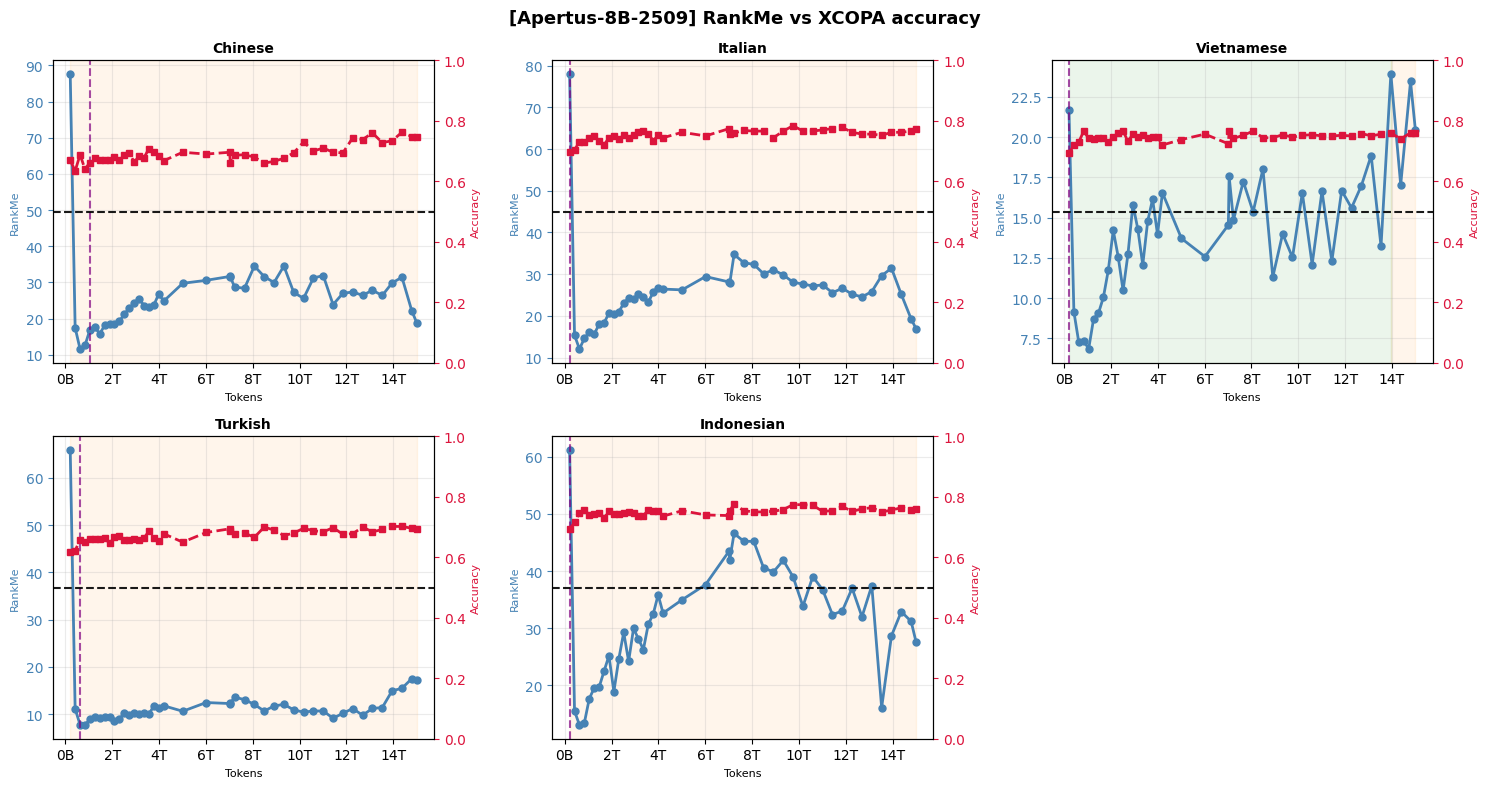

Saved: plots/overlay_xcopa_apertus.png


In [10]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        plot_overlay(d["df_eval"], d["df_layer"], d["df_phases"], d["df_grokking"],
                     cfg["task_languages"], cfg["random_chance"],
                     d["checkpoints_all"], d["token_counts"], d["langs_sorted"],
                     cfg["model_label"], cfg["plots_dir"], model_key=m)
    else:
        print(f"[{m}] Skipping overlay plots — run evaluate.py first.")

## RankMe Findings

### FuxiTranyu-8B

**Phase structure (RankMe, all 14 languages)**

- RankMe peaks at the very first checkpoint (10B tokens) for every language — the entropy-seeking phase, if it existed, happened before our earliest observation. Compression-seeking begins immediately and lasts the full 583B tokens of training.
- Because all languages share the same compression onset (zero variance), timing-based correlations (onset, duration) are undefined.
- RankMe magnitude varies substantially across languages both at the start (Arabic/Hindi/Swahili/Indonesian ~56–118; Japanese/Chinese/German ~295–374) and at the end (Swahili 38; Japanese 182), providing cross-language signal even though timing is uniform.
- Higher-resource and Latin-script languages maintain richer representations throughout training; low-resource and morphologically complex languages compress more aggressively.

**m-MMLU knowledge accuracy (8 languages)**

- Accuracy remains at random chance (~25%) for all 8 languages across all 57 evaluated checkpoints — no language exceeds the 40% grokking threshold. No grokking is detected.
- The spread in peak accuracy is negligible (0.269–0.276, < 1 pp), within noise. No RankMe predictor shows a significant correlation with m-MMLU performance (all |Sp r| < 0.33, all p > 0.42).
- Factual knowledge retrieval (m-MMLU) does not emerge during pre-training for this model, regardless of language or representation geometry.

**XCOPA commonsense accuracy (5 languages)**

- All 5 languages exceed the 50% baseline from the earliest checkpoints, indicating commonsense reasoning emerges very early in training.
- Grokking is detected in 4 of 5 languages: Vietnamese first (126B), Italian and Indonesian simultaneously (241B), Chinese (325B). Turkish accuracy improves too gradually to trigger the threshold.
- Performance ranking: Vietnamese (0.736) > Italian (0.718) > Indonesian (0.704) > Chinese (0.664) > Turkish (0.644). Latin-script languages outperform, consistent with cross-lingual transfer from English.
- **No significant correlation between any RankMe predictor and XCOPA outcomes.** RankMe at the last checkpoint correlates marginally with grokking onset (Sp r=+0.95, p=0.051, n=4) but is positive — higher final RankMe associates with *later* grokking, a counterintuitive direction that does not survive multiple comparisons. Peak accuracy shows no relationship with any predictor (all p > 0.39). RankMe geometry measured on Wikipedia text does not reliably predict XCOPA performance for this model.

---

### Apertus-8B-2509

**Phase structure (RankMe, all 14 languages)**

- Two qualitatively different patterns emerge across languages:
  - **10 languages** (Chinese, English, Finnish, French, German, Indonesian, Italian, Japanese, Spanish, Turkish) peak at the first observed checkpoint (210B) — only the compression-seeking phase is visible.
  - **4 languages** (Arabic, Swahili, Vietnamese, Hindi) show a visible entropy-seeking phase: RankMe rises from 210B before peaking. Arabic and Swahili peak at ~14800B, Vietnamese at ~13950B, Hindi at ~7230B — near the end of training.
- The split follows resource level and script: low-resource and non-Latin/non-CJK languages (Arabic, Swahili, Hindi) start with very low initial RankMe (14–18) and continue building representations far into training, while high-resource languages reach their representational peak early.
- RankMe at the first checkpoint varies dramatically: English/German/Japanese (109–175) vs Arabic/Swahili/Hindi (14–20), a 10× spread that provides strong cross-language signal.

**m-MMLU knowledge accuracy (8 languages) — strong findings**

- Unlike Fuxi, Apertus grokked on m-MMLU in every evaluated language. Grokking onset spans 840B (English) to 7047B (Hindi), with Arabic (3150B) and Hindi (7047B) lagging substantially. Peak accuracy spans 0.491 (Hindi) to 0.625 (English).
- **The initial representational richness (RankMe at first checkpoint) is the strongest single predictor of both outcomes:**
  - → Peak m-MMLU accuracy: **Spearman r=+0.833, p=0.010; Pearson r=+0.904, p=0.002** (n=8). Languages whose representations are richer at 210B tokens achieve significantly higher factual accuracy at the end of training.
  - → Grokking onset: **Spearman r=−0.812, p=0.014** (n=8). Languages with richer initial representations grok earlier.
- **The rate of RankMe decline is an equally strong predictor:**
  - → Peak accuracy: **Spearman r=+0.810, p=0.015; Pearson r=+0.876, p=0.004** (n=8). Faster compression correlates with higher accuracy — not because compression is beneficial, but because languages that compress faster also started with richer representations.
  - → Grokking onset: **Spearman r=−0.786, p=0.021** (n=8). Faster compression → earlier grokking.
- Compression onset and duration are also significant but reflect the same underlying resource-level axis (Arabic/Swahili/Hindi start compressing thousands of tokens later, and score lower).
- RankMe at the *last* checkpoint shows no significant correlation with either outcome (|Sp r| < 0.26, p > 0.53) — it is the *starting* richness, not the *ending* richness, that matters for Apertus.
- **Interpretation:** Initial representational richness at 210B tokens acts as a proxy for how much multilingual pre-training signal a language has absorbed by that point. Languages with richer early representations (high-resource, Latin/CJK-script) both achieve higher factual accuracy and transition to knowledge retrieval earlier.

**XCOPA commonsense accuracy (5 languages)**

- All 5 languages grok, and grokking happens earlier than in Fuxi: Italian, Vietnamese, and Indonesian from the very first evaluated checkpoint (210B); Turkish at 630B; Chinese at 1050B.
- Peak accuracy is uniformly high: Italian (0.784), Vietnamese (0.766), Indonesian (0.776), Chinese (0.762), Turkish (0.702) — all substantially above Fuxi's range (0.644–0.736).
- No significant RankMe correlation with XCOPA outcomes (all p > 0.3). The ceiling-effect-like clustering of XCOPA accuracy across languages likely suppresses detectable geometry–performance relationships.

---
## Extended Analysis: AlphaReQ

AlphaReQ (α) measures the power-law exponent of the eigenvalue spectrum of the activation matrix. Unlike RankMe, which captures *how many* dimensions are used, α captures the *shape* of the spectrum:

- **Lower α** → heavier-tailed spectrum → more implicit self-regularization → associated with better generalisation.
- **Higher α** → lighter-tailed spectrum → less regularization.

The **α trough** is the training checkpoint where α reaches its global minimum — the point of maximum self-regularization. It marks the boundary between two phases we define for this analysis:

- **Regularization-increasing** (α ↓): α falls from the first checkpoint to the trough — the model is gaining self-regularization.
- **Regularization-decreasing** (α ↑): α rises from the trough to the end of training — self-regularization weakens slightly as the model continues to adapt.

Unlike the RankMe analysis where the peak was at 10B for every language, the α trough position **varies across languages** (189B–531B), making the correlation analysis more informative.

### Phase Identification (AlphaReQ)

In [11]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    df_alpha_phases = compute_alpha_phases(d["df_layer"], d["checkpoints_all"], d["token_counts"])
    d["df_alpha_phases"] = df_alpha_phases

    display_cols = {
        "language":                       "language",
        "trough_tokens":                  "trough (B)",
        "reg_increasing_onset_tokens":    "reg-increasing onset (B)",
        "reg_increasing_rate":            "rate of α decline (α/B)",
        "reg_decreasing_onset_tokens":    "reg-decreasing onset (B)",
        "reg_decreasing_duration_tokens": "reg-decreasing duration (B)",
    }
    print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
    print(df_alpha_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))


── FuxiTranyu-8B ────────────────────────────────────────
  language  trough (B)  reg-increasing onset (B)  rate of α decline (α/B)  reg-decreasing onset (B)  reg-decreasing duration (B)
    Arabic       531.0                      10.0                 0.000201                     531.0                         62.0
   Chinese       325.0                      10.0                 0.000243                     325.0                        268.0
   English       325.0                      10.0                 0.000210                     325.0                        268.0
   Finnish       189.0                      10.0                 0.000256                     189.0                        404.0
    French       325.0                      10.0                 0.000201                     325.0                        268.0
    German       241.0                      10.0                 0.000268                     241.0                        352.0
     Hindi       531.0                

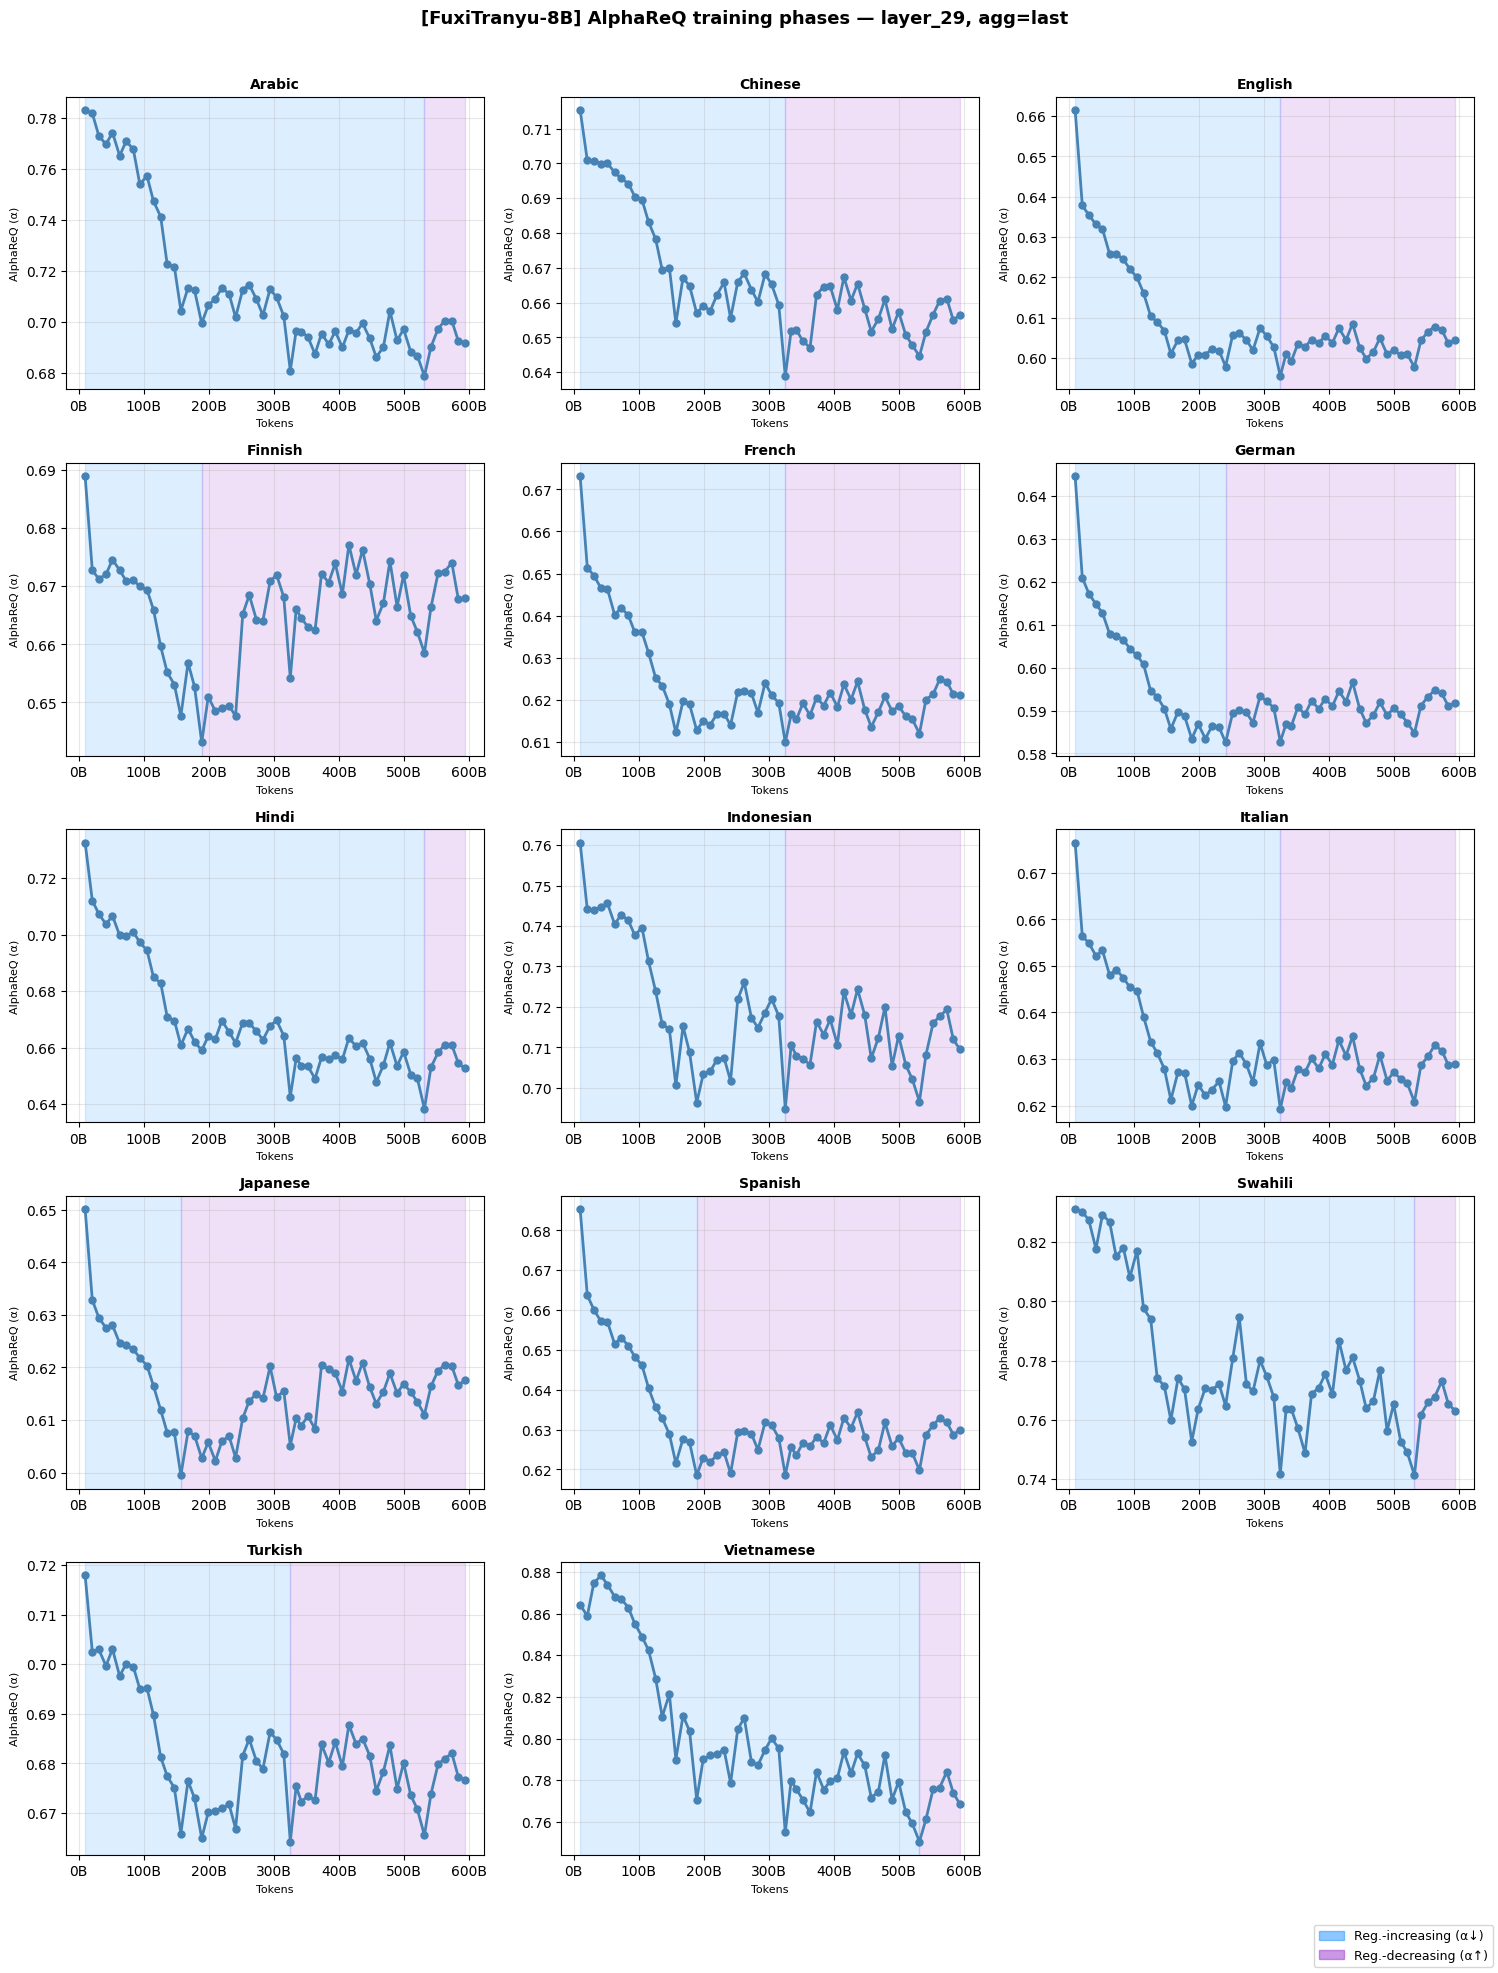

Saved: plots/alpha_phases_fuxi.png


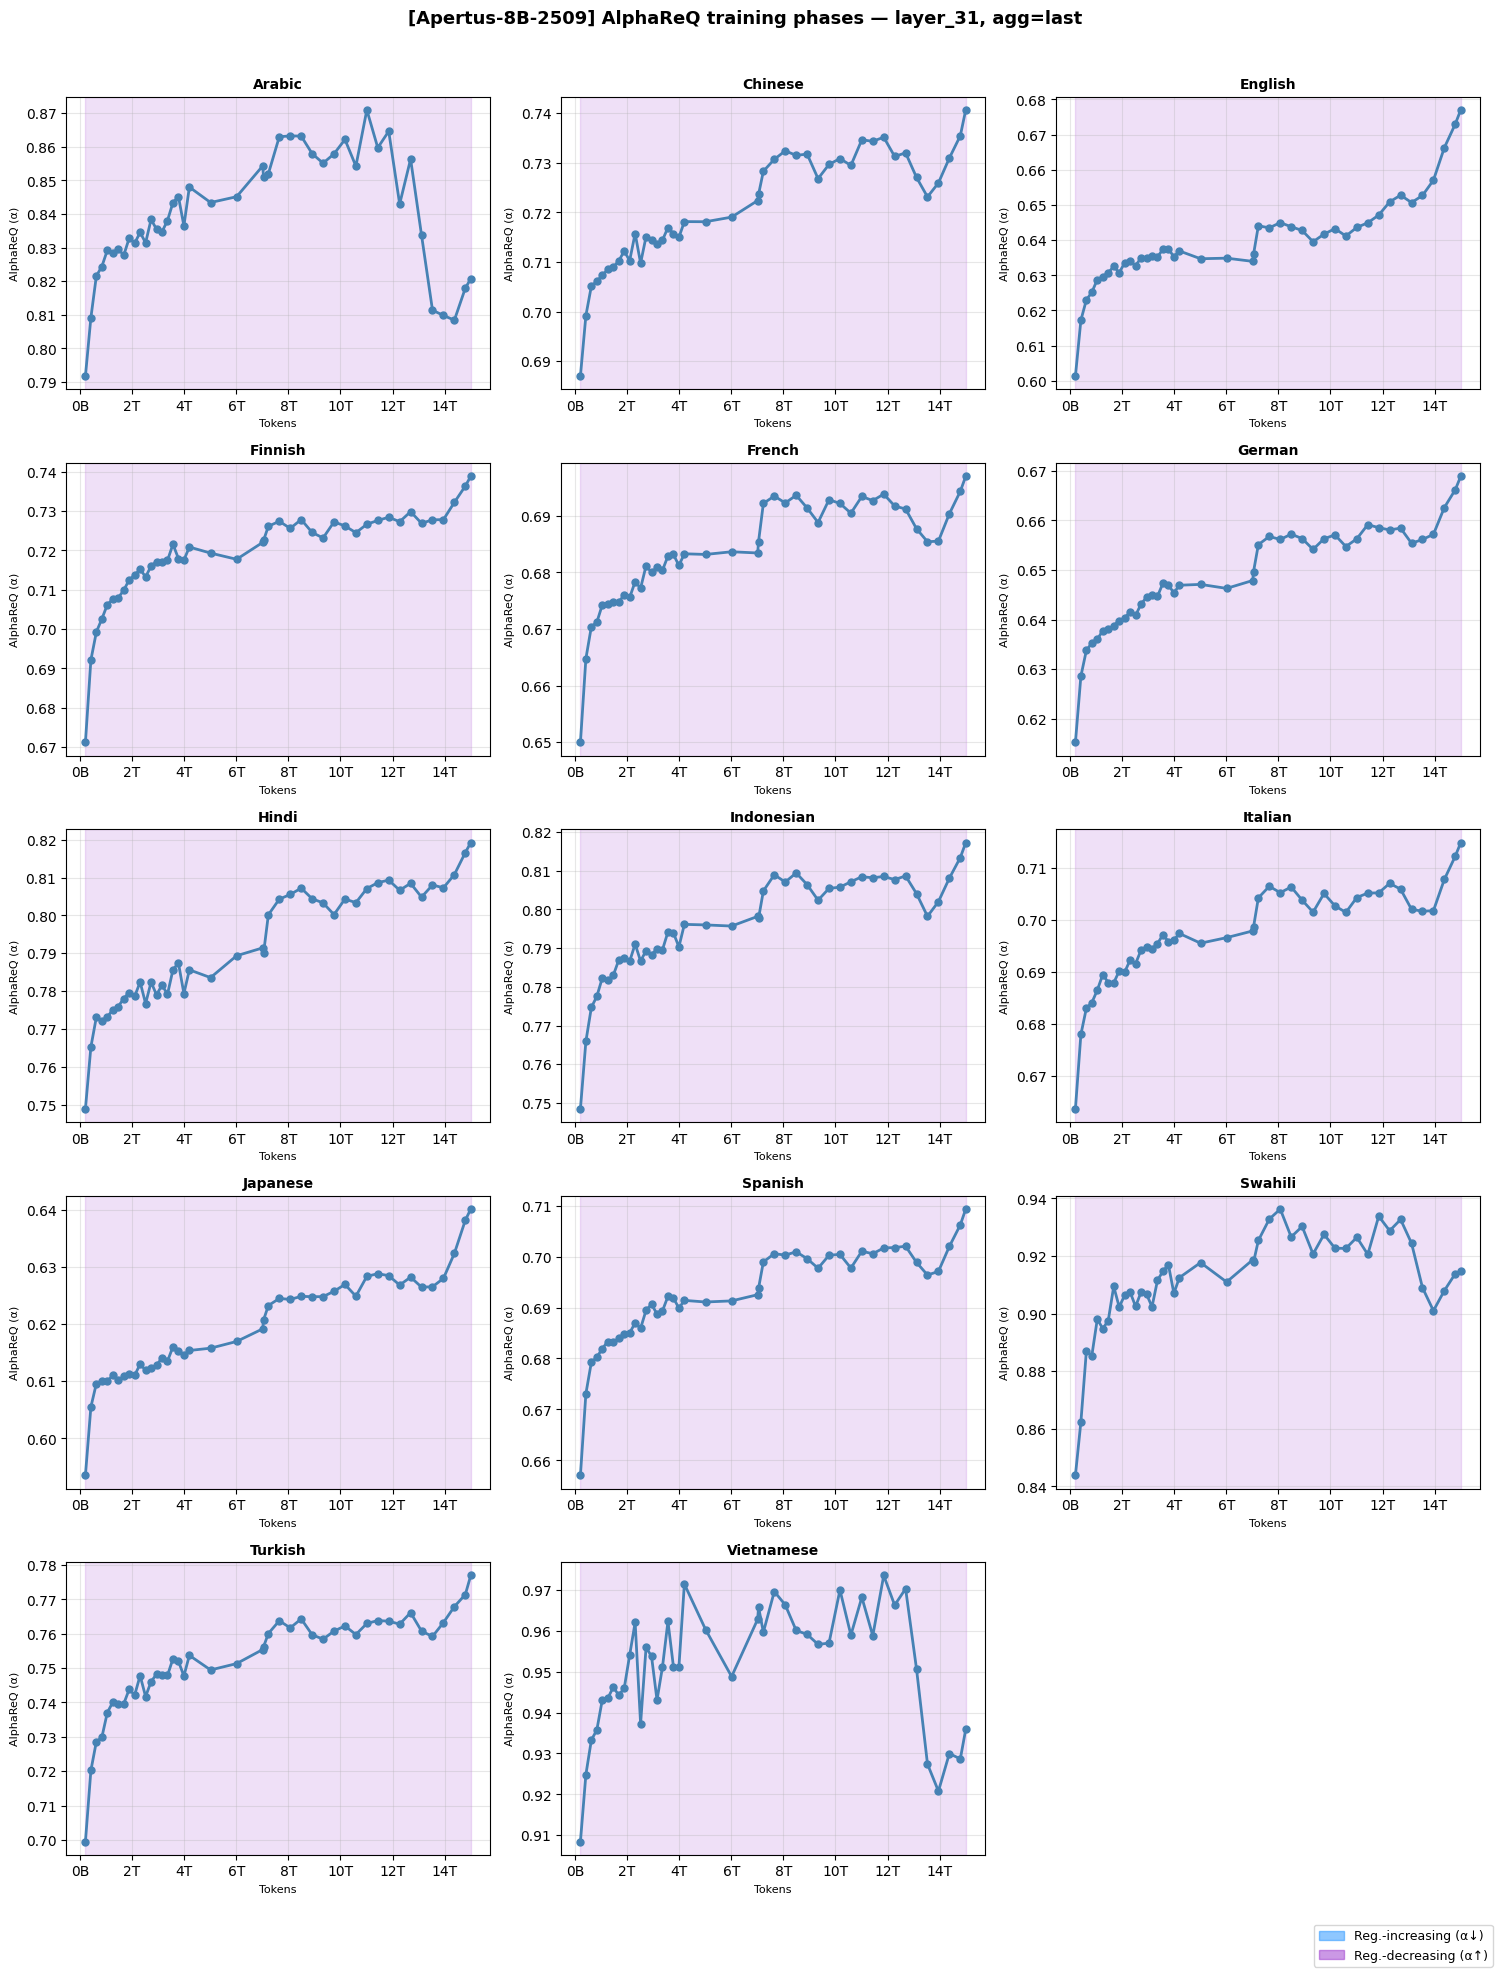

Saved: plots/alpha_phases_apertus.png


In [12]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    plot_alpha_phases(d["df_layer"], d["df_alpha_phases"], d["checkpoints_all"], d["token_counts"],
                      d["langs_sorted"], cfg["model_label"], cfg["layer"], cfg["aggregation"],
                      cfg["plots_dir"], model_key=m)

### Overlay Plots (AlphaReQ)

Each panel shows AlphaReQ (blue, left axis) overlaid with downstream accuracy (red, right axis). Shaded regions mark the two α phases (blue = regularization-increasing, purple = regularization-decreasing). The black dashed line marks random-chance baseline. The purple vertical dashed line marks grokking onset where detected.

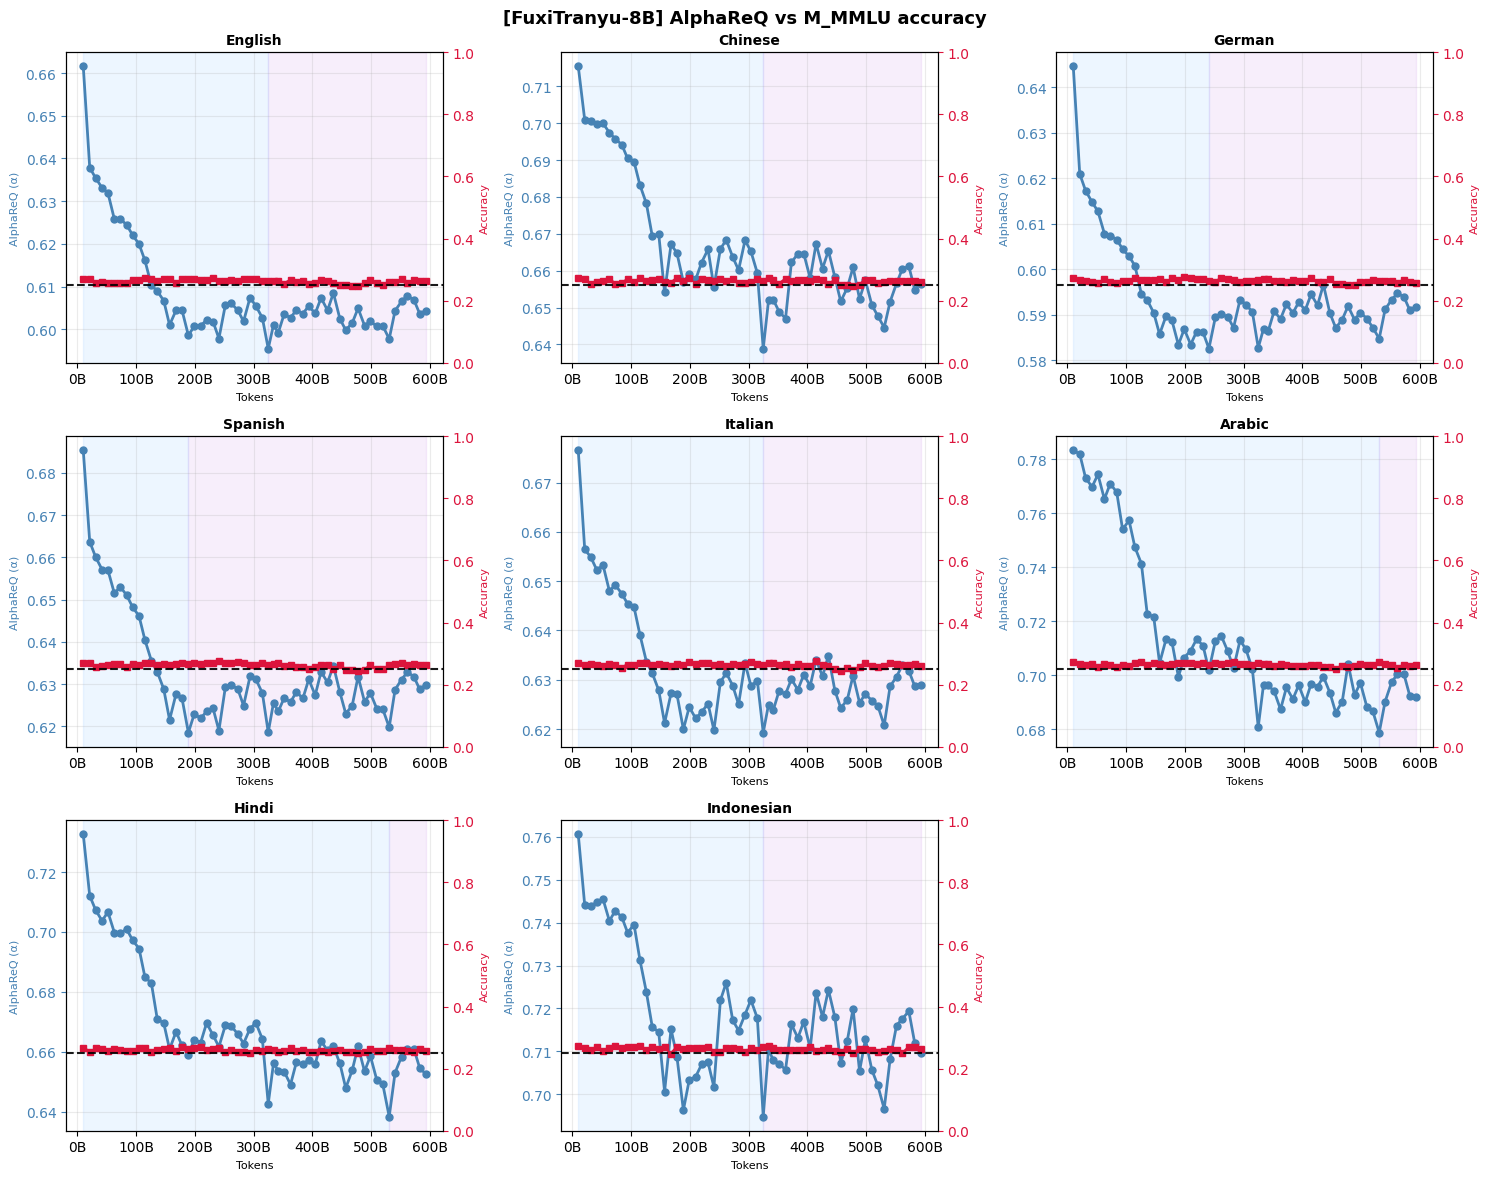

Saved: plots/alpha_overlay_m_mmlu_fuxi.png


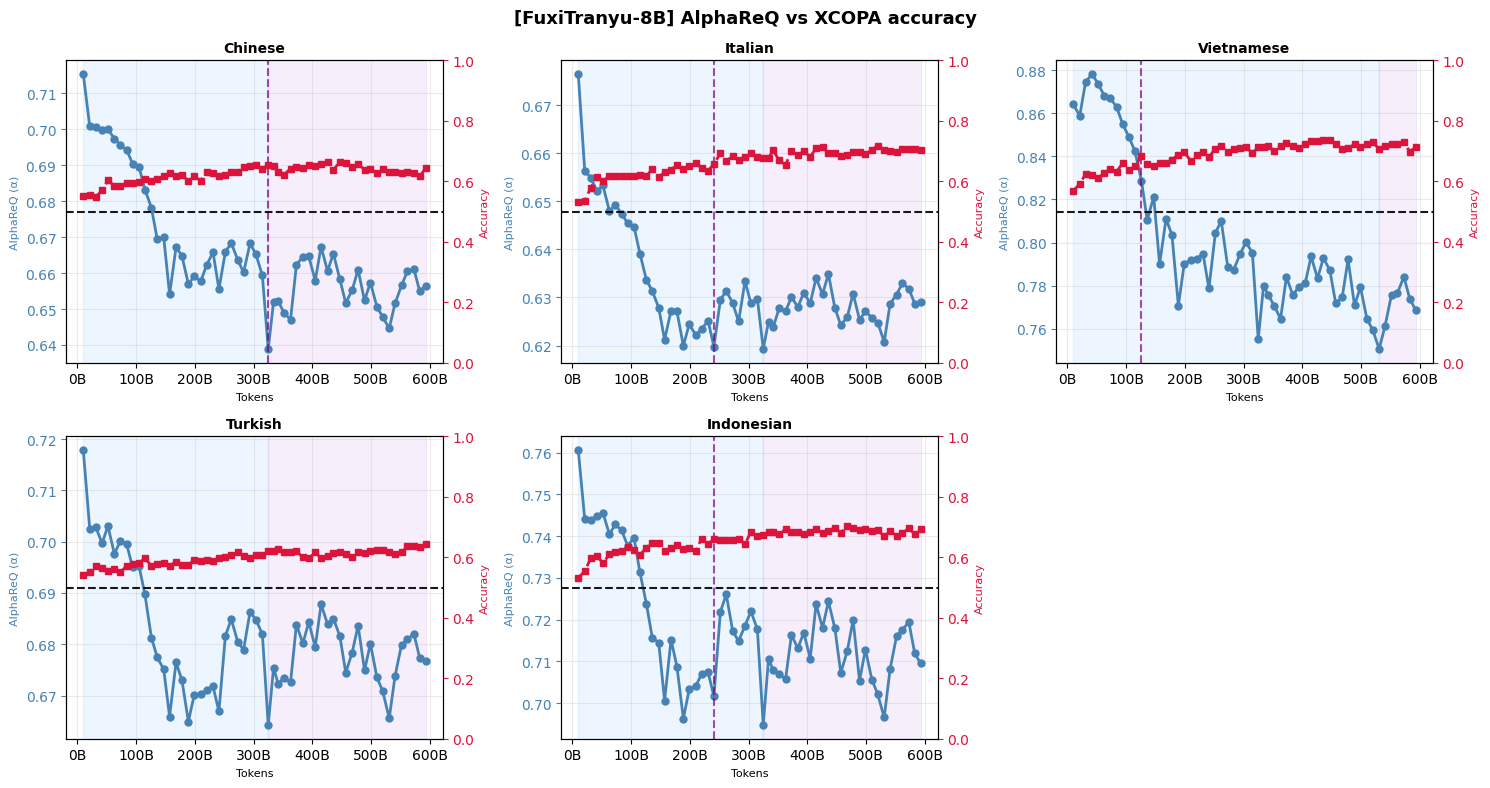

Saved: plots/alpha_overlay_xcopa_fuxi.png


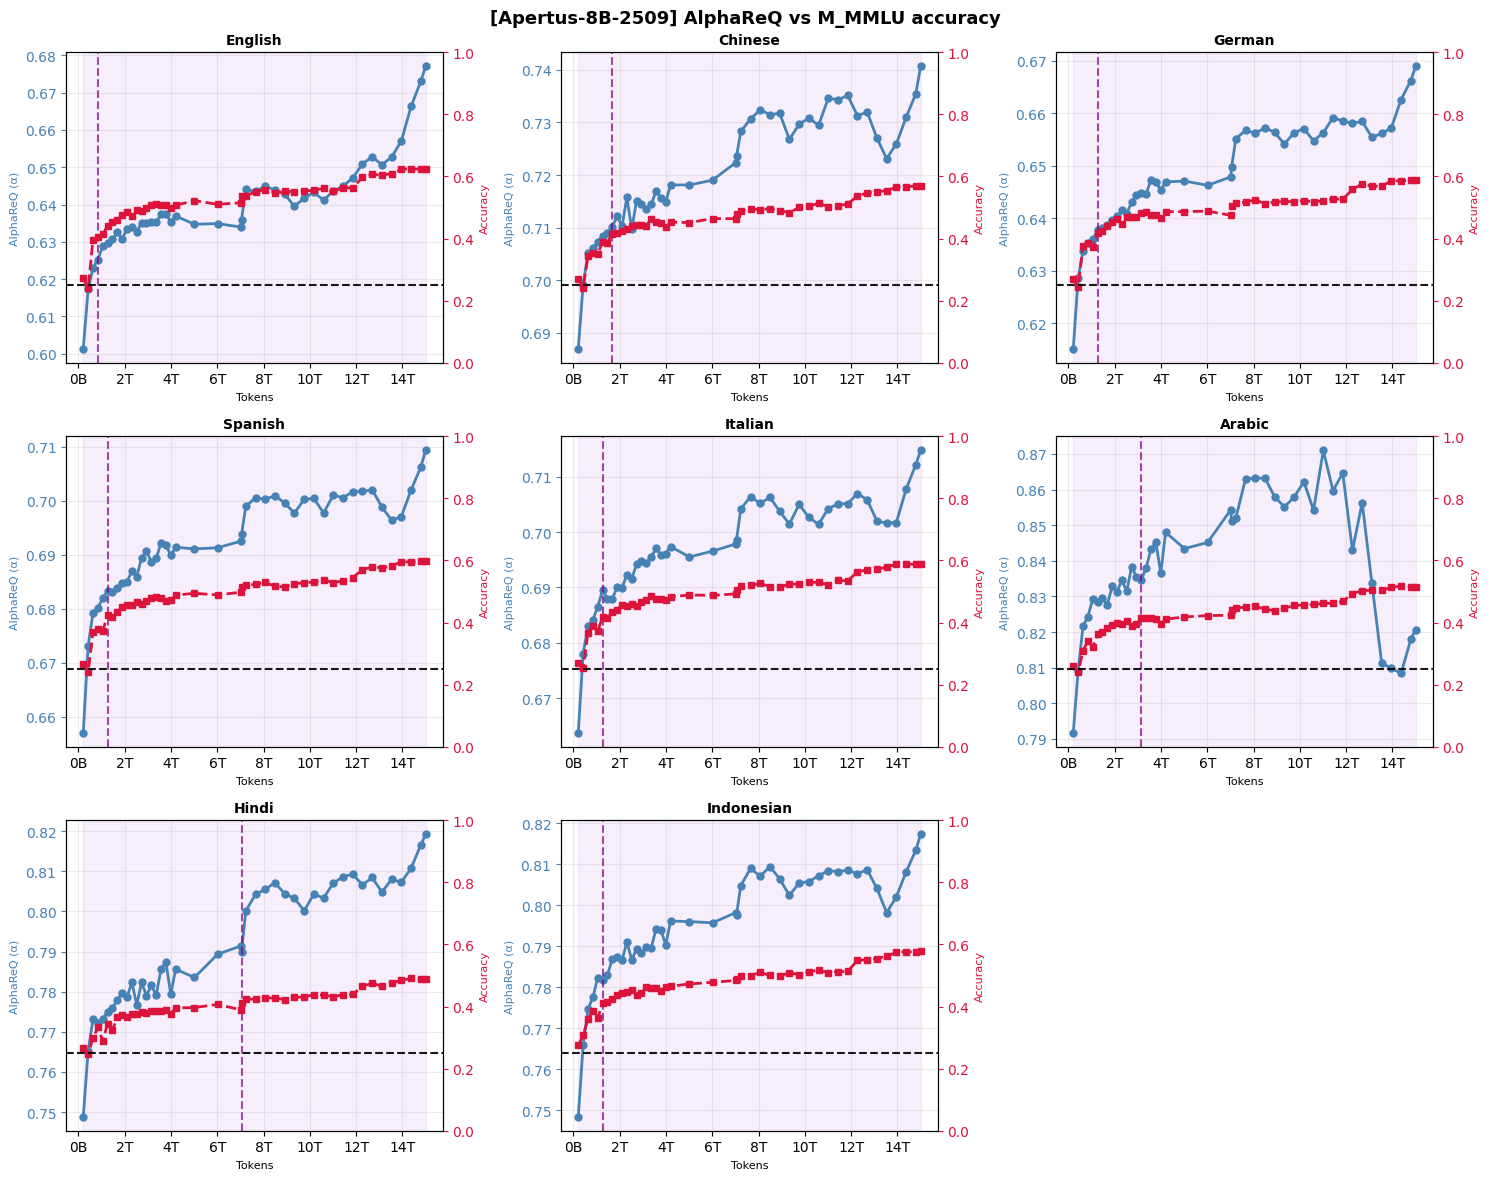

Saved: plots/alpha_overlay_m_mmlu_apertus.png


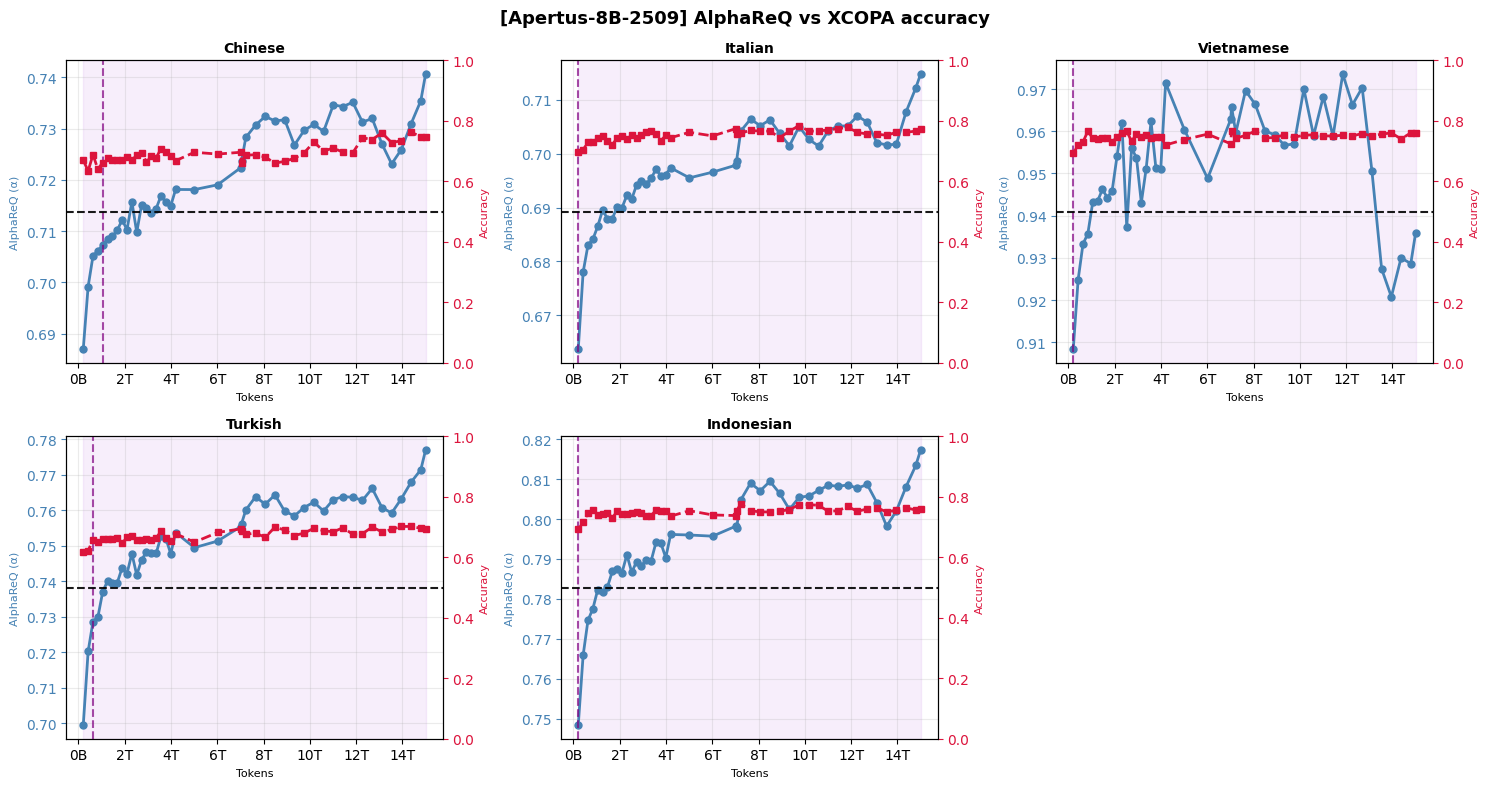

Saved: plots/alpha_overlay_xcopa_apertus.png


In [13]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"]:
        plot_alpha_overlay(d["df_eval"], d["df_layer"], d["df_alpha_phases"], d["df_grokking"],
                           cfg["task_languages"], cfg["random_chance"],
                           d["checkpoints_all"], d["token_counts"], d["langs_sorted"],
                           cfg["model_label"], cfg["plots_dir"], model_key=m)
    else:
        print(f"[{m}] Skipping AlphaReQ overlay plots — run evaluate.py first.")

### Correlation Analysis (AlphaReQ)

Tests whether the position of the α trough (onset of the regularization-decreasing phase) or the rate of α decline (drop in α per billion tokens during the regularization-increasing phase) predicts downstream performance. Unlike the RankMe analysis where all languages shared the same compression onset, the α trough varies across languages (189B–531B), so correlations here carry real predictive signal.

In [14]:
for m in MODELS:
    d = data[m]
    cfg = d["cfg"]
    if d["eval_available"] and not d["df_grokking"].empty:
        df_alpha_correlations = compute_alpha_correlations_table(d["df_grokking"], d["df_alpha_phases"])
        d["df_alpha_correlations"] = df_alpha_correlations
        print(f"\n── {cfg['model_label']} ────────────────────────────────────────")
        print(df_alpha_correlations.to_string(index=False))
    else:
        d["df_alpha_correlations"] = pd.DataFrame()
        print(f"[{m}] Skipping AlphaReQ correlation analysis — no eval data available.")


── FuxiTranyu-8B ────────────────────────────────────────
  task             predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu Reg.-decreasing onset (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu Reg.-decreasing onset (B)      Peak accuracy            8     -0.6385      0.0884    -0.6867     0.0599
m_mmlu   Rate of α decline (α/B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu   Rate of α decline (α/B)      Peak accuracy            8      0.4286      0.2894     0.5585     0.1502
 xcopa Reg.-decreasing onset (B) Grokking onset (B)            4     -0.8165      0.1835    -0.8748     0.1252
 xcopa Reg.-decreasing onset (B)      Peak accuracy            5      0.7071      0.1817     0.6263     0.2583
 xcopa   Rate of α decline (α/B) Grokking onset (B)            4      0.3162      0.6838     0.3053     0.6947
 xcopa   Rate of α decline (α/B)      Peak accuracy  

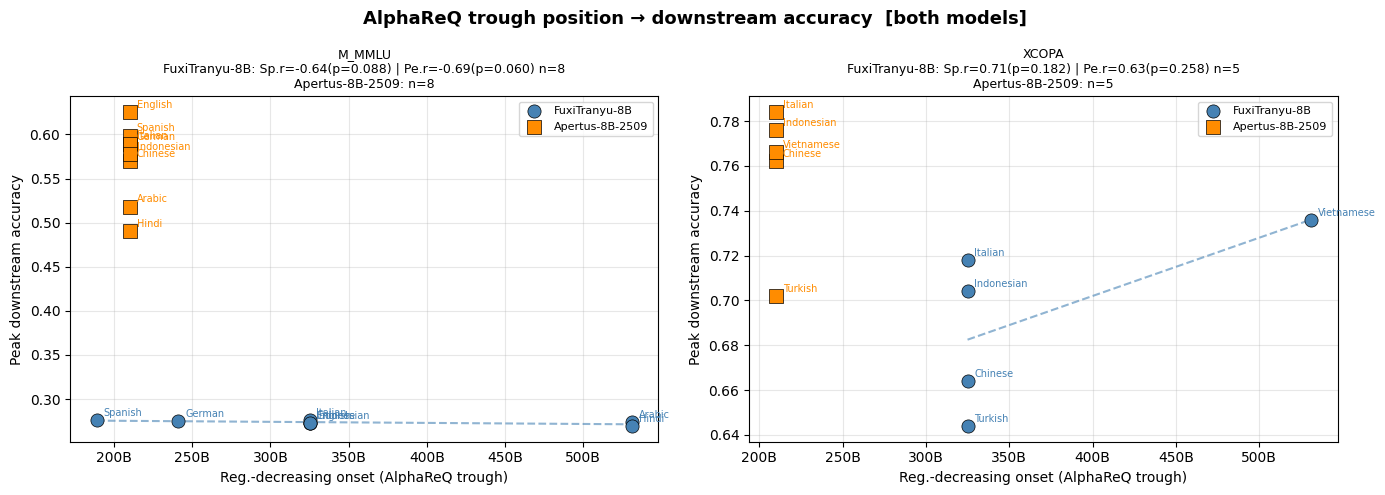

Saved: plots/alpha_correlation_scatter.png


In [15]:
alpha_models_data = [
    {
        "label":           data[m]["cfg"]["model_label"],
        "df_grokking":     data[m].get("df_grokking",     pd.DataFrame()),
        "df_alpha_phases": data[m].get("df_alpha_phases", pd.DataFrame()),
        "color":           data[m]["color"],
        "marker":          data[m]["marker"],
    }
    for m in MODELS if data[m]["eval_available"]
]
if alpha_models_data:
    plot_alpha_correlation_scatter_combined(alpha_models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping AlphaReQ correlation scatter — no eval data available.")

**FuxiTranyu-8B:** The rate of α decline shows no significant relationship with grokking onset (Sp r=+0.32, p=0.68, n=4) or peak accuracy (Sp r=+0.30, p=0.62, n=5). The correlation is small and not significant for this model and dataset.

**Apertus-8B-2509:** The α trough falls at the very first observed checkpoint (210B) for all languages, so the rate of α decline cannot be computed — this panel contains no Apertus points. See the AlphaReQ Findings section below.

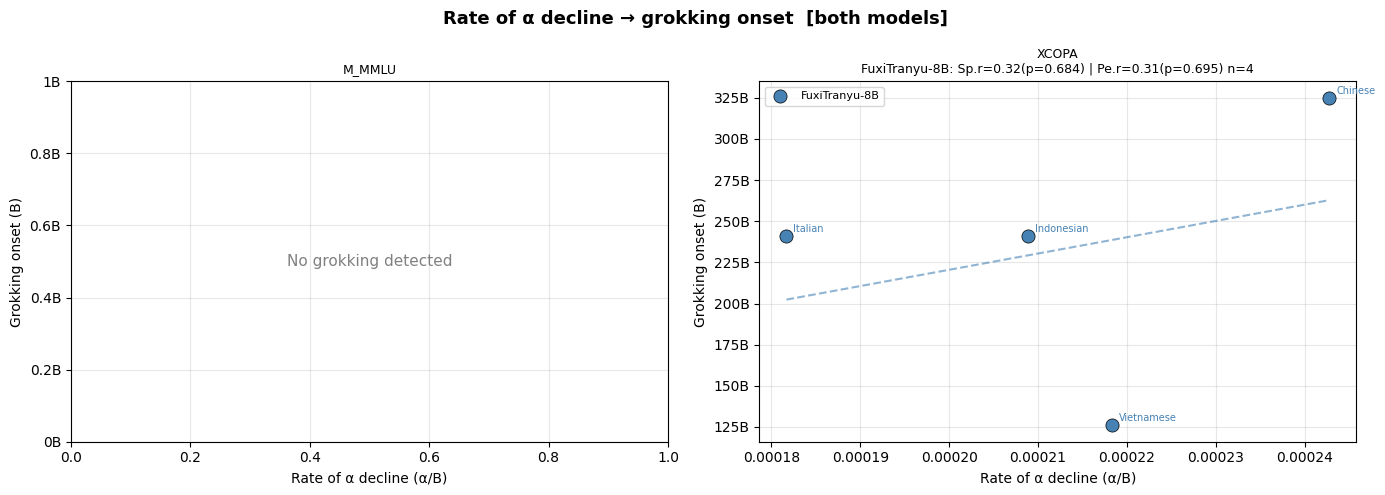

Saved: plots/alpha_rate_scatter.png


In [16]:
if alpha_models_data:
    plot_alpha_rate_scatter_combined(alpha_models_data, data[MODELS[0]]["cfg"]["plots_dir"])
else:
    print("[INFO] Skipping AlphaReQ rate scatter — no eval data available.")

### AlphaReQ Findings

#### FuxiTranyu-8B

**Phase structure (AlphaReQ, all 14 languages)**

- Both phases are present in every language: α falls to a trough then rises, confirming the regularization-increasing → regularization-decreasing pattern throughout training.
- The α trough position varies across languages (157B–531B), unlike RankMe where all languages peak at 10B. Japanese reaches the trough earliest (157B), Finnish and Spanish next (189B), most languages cluster around 241–325B, while Arabic, Hindi, Swahili, and Vietnamese trough latest (531B) — mirroring the resource-level ordering seen in RankMe.
- The rate of α decline also varies: Japanese and Spanish fastest (0.000344–0.000373 α/B), Turkish and Swahili slowest (0.000170–0.000173 α/B).

**Correlation analysis**

- **m-MMLU:** Reg-decreasing onset (trough position) shows a marginal negative correlation with peak m-MMLU accuracy (Sp r=−0.639, p=0.088, n=8): languages with an earlier trough tend to score higher. This does not reach significance and should be interpreted with caution.
- **XCOPA:** Reg-decreasing onset shows a strong trend with grokking onset (Sp r=−0.817, p=0.183, n=4): languages reaching peak regularization earlier also tend to grok earlier — an intuitive result, but n=4 is too small to reach significance. Rate of α decline shows no relationship with grokking onset (Sp r=+0.32, p=0.68) or peak accuracy.
- **No AlphaReQ correlation reaches statistical significance for this model.** The trough position is a useful ordering variable but does not provide independent predictive power beyond the resource-level axis already captured by RankMe.

---

#### Apertus-8B-2509

**Phase structure (AlphaReQ, all 14 languages)**

- The α trough falls at exactly 210B (the first observed checkpoint) for all 14 languages — the regularization-increasing phase (α declining from training start to the trough) is entirely unobservable with this checkpoint grid. We only see the regularization-decreasing phase (α rising from 210B onward).
- This is the AlphaReQ analogue of Fuxi's RankMe situation: just as Fuxi's RankMe had already peaked by the first checkpoint, Apertus's α has already troughed.
- Because no pre-trough data exists, the rate of α decline cannot be computed for any language. All AlphaReQ timing correlations for Apertus are undefined.
- **AlphaReQ analysis is uninformative for Apertus** with the current checkpoint resolution. Earlier checkpoints (< 210B) would be needed to observe the regularization-increasing phase and compute meaningful rates.


### Workflow
```bash
# 1 — Submit one cluster job per checkpoint (see README)
for ckpt in 10B 115B ...; do
    ./downstream_evaluation/submit_eval.sh $ckpt fuxi
done

# 2 — After all jobs complete, merge once manually (see README)

# 3 — Rerun this notebook — all cells activate automatically
```